=== Mann–Kendall (pymannkendall) ===
Land  Terra (MOD08): trend=no trend, p=0.652
Land  Aqua  (MYD08): trend=no trend, p=0.535
Cloud Terra (MOD08): trend=increasing, p=0.006
Cloud Aqua  (MYD08): trend=increasing, p=0.001


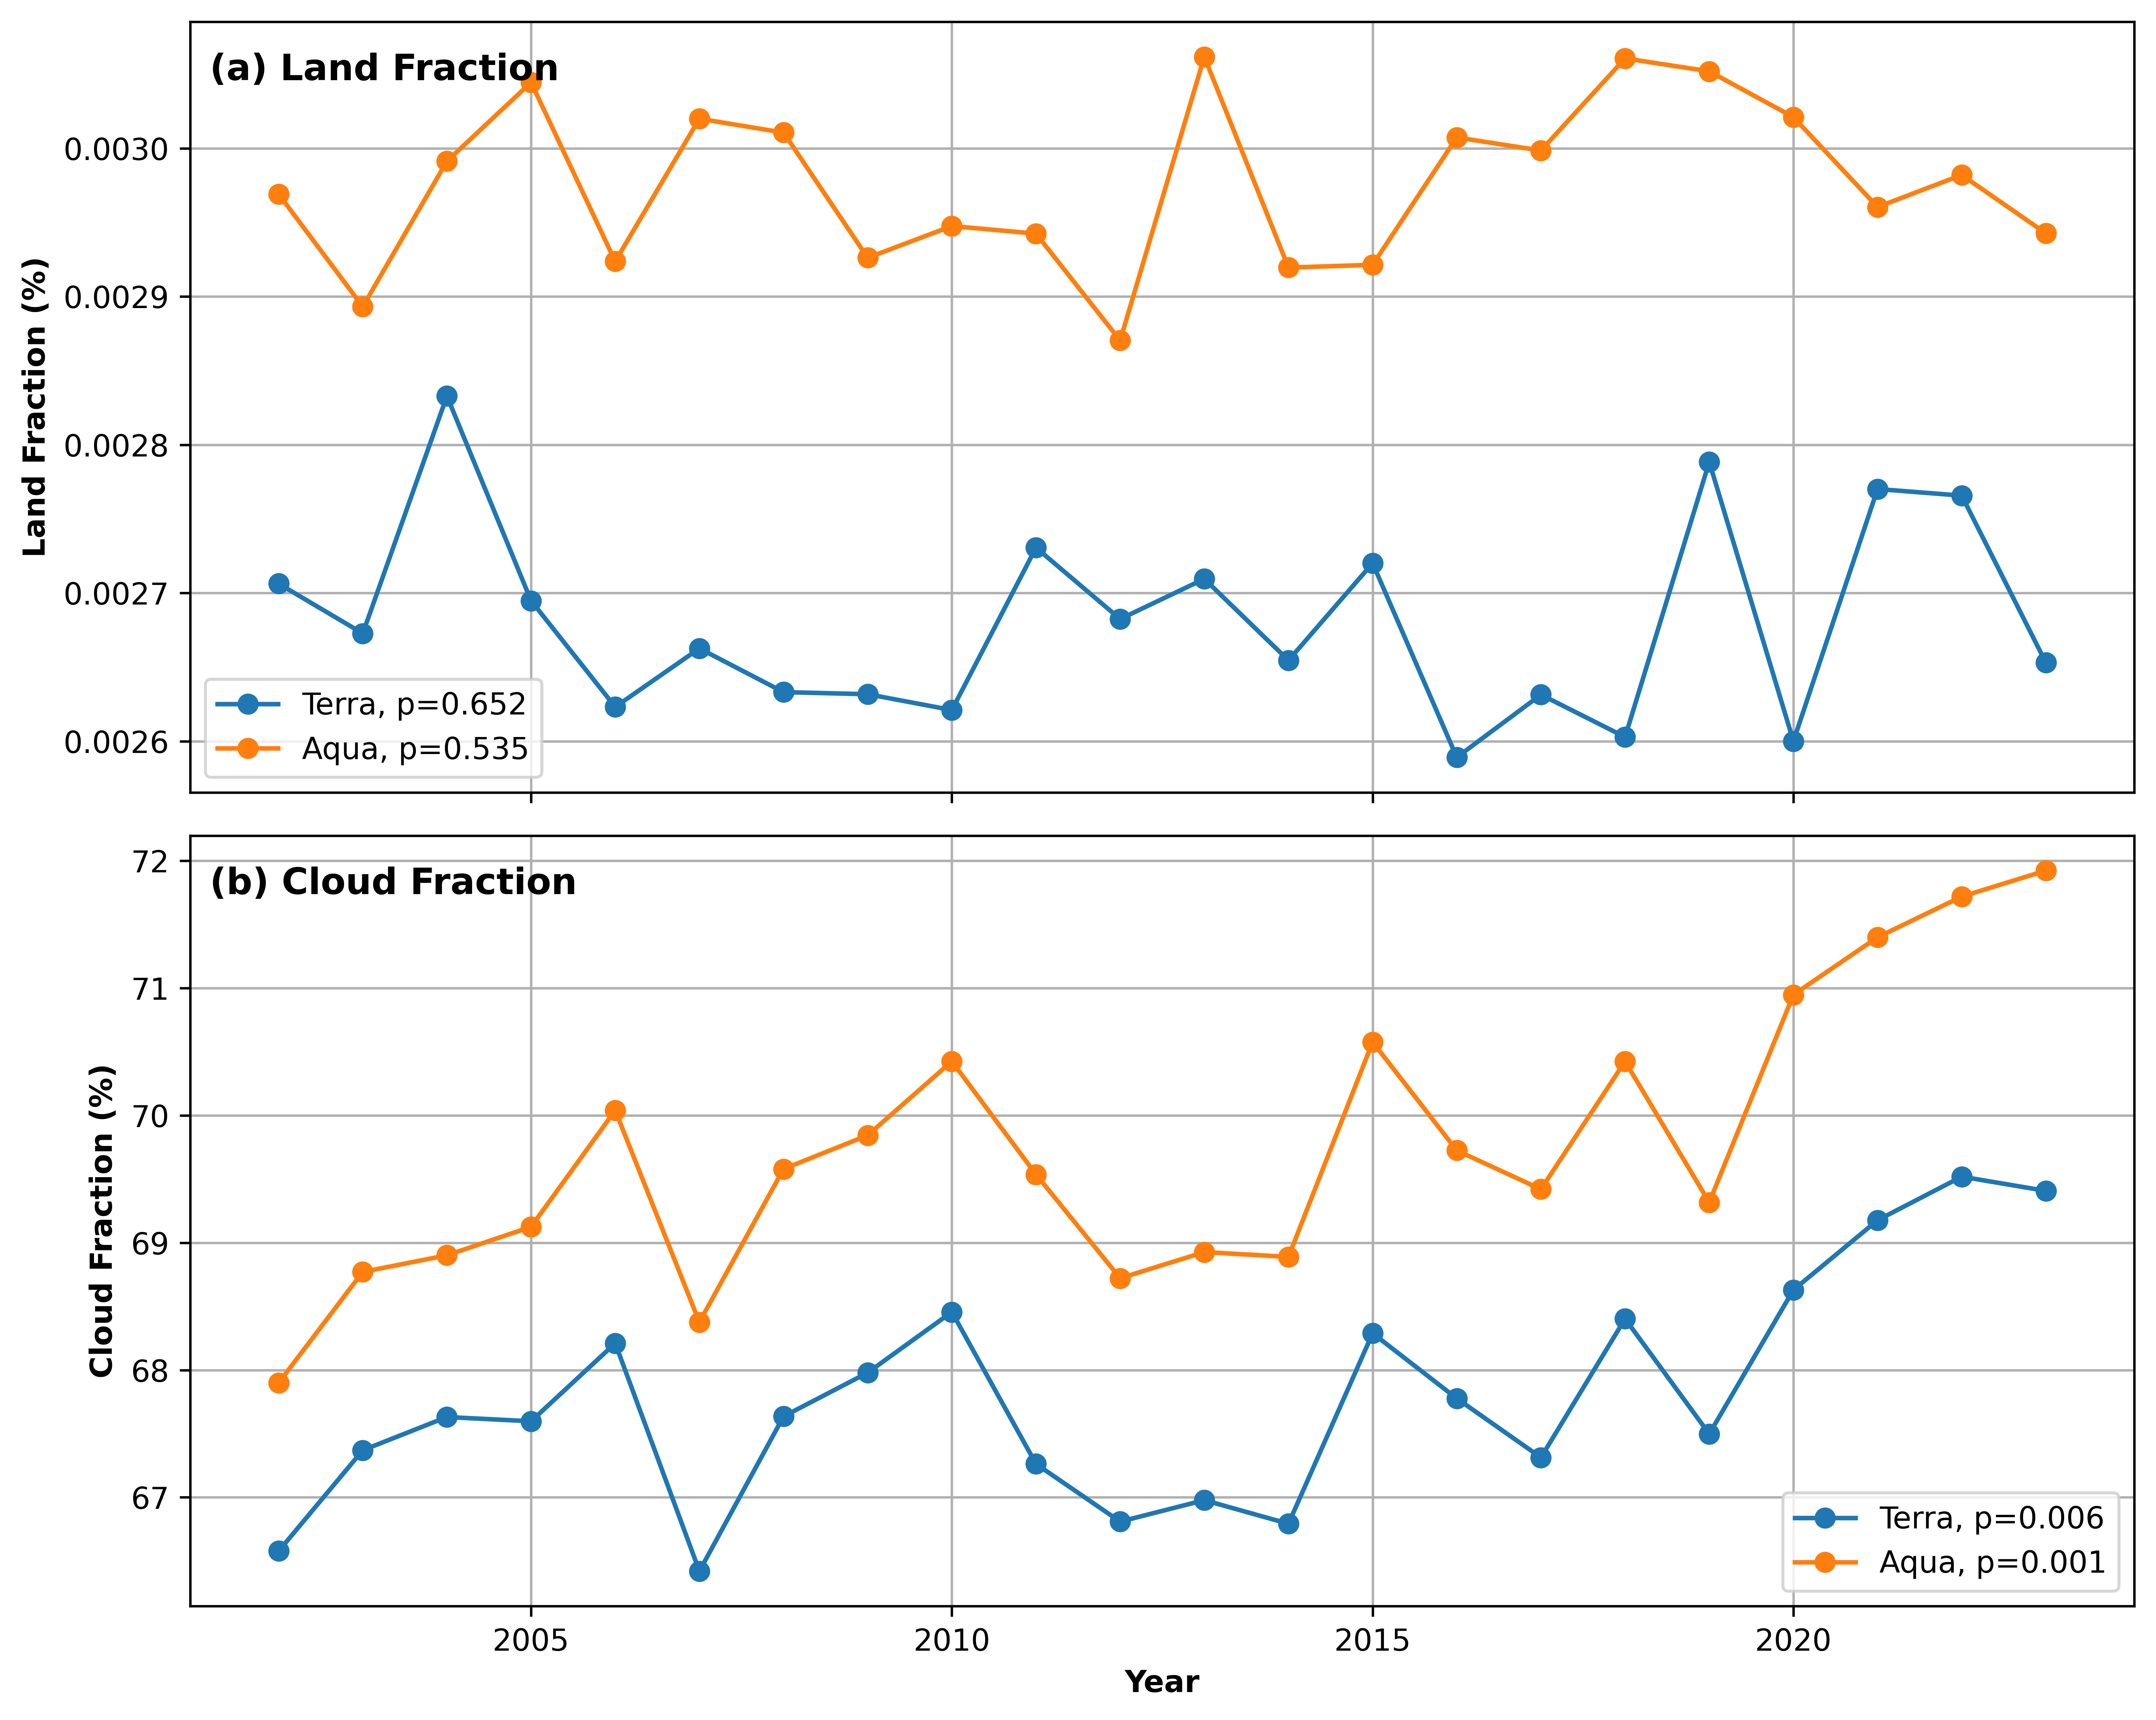

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pymannkendall as mk  # <--- use MK package

# ---------- Load Data ----------
path_mod = r"G:\Hangkai\Anttarctic Vegetation Dynamic\MOD08M3_Cloud_LandFrac_Seasons_South60.csv"
path_myd = r"G:\Hangkai\Anttarctic Vegetation Dynamic\MYD08M3_Cloud_LandFrac_Seasons_South60.csv"

mod = pd.read_csv(path_mod)
myd = pd.read_csv(path_myd)

# Filter 2002–2023
mod_f = mod[(mod["season_year"] >= 2002) & (mod["season_year"] <= 2023)]
myd_f = myd[(myd["season_year"] >= 2002) & (myd["season_year"] <= 2023)]

years = mod_f["season_year"].values  # same for both

# ---------- MK tests using pymannkendall ----------
# Land fraction
res_mod_land = mk.original_test(mod_f["land_frac_pct"])
res_myd_land = mk.original_test(myd_f["land_frac_pct"])

# Cloud fraction
res_mod_cloud = mk.original_test(mod_f["cloud_pct"])
res_myd_cloud = mk.original_test(myd_f["cloud_pct"])

# Grab p-values (and you can also use res_*.z, res_*.trend, etc.)
p_mod_land = res_mod_land.p
p_myd_land = res_myd_land.p
p_mod_cloud = res_mod_cloud.p
p_myd_cloud = res_myd_cloud.p

print("=== Mann–Kendall (pymannkendall) ===")
print(f"Land  Terra (MOD08): trend={res_mod_land.trend}, p={p_mod_land:.3f}")
print(f"Land  Aqua  (MYD08): trend={res_myd_land.trend}, p={p_myd_land:.3f}")
print(f"Cloud Terra (MOD08): trend={res_mod_cloud.trend}, p={p_mod_cloud:.3f}")
print(f"Cloud Aqua  (MYD08): trend={res_myd_cloud.trend}, p={p_myd_cloud:.3f}")

# ---------- Plotting ----------
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True, dpi=600)

# Panel (a): Land fraction
axs[0].plot(
    years,
    mod_f["land_frac_pct"],
    label=f"Terra, p={p_mod_land:.3f}",
    marker="o"
)
axs[0].plot(
    years,
    myd_f["land_frac_pct"],
    label=f"Aqua, p={p_myd_land:.3f}",
    marker="o"
)
axs[0].set_ylabel("Land Fraction (%)", fontweight="bold")
axs[0].legend()
axs[0].grid(True)
axs[0].text(0.01, 0.96, "(a) Land Fraction", transform=axs[0].transAxes,
            fontsize=12, fontweight="bold", va="top")

# Panel (b): Cloud fraction
axs[1].plot(
    years,
    mod_f["cloud_pct"],
    label=f"Terra, p={p_mod_cloud:.3f}",
    marker="o"
)
axs[1].plot(
    years,
    myd_f["cloud_pct"],
    label=f"Aqua, p={p_myd_cloud:.3f}",
    marker="o"
)
axs[1].set_ylabel("Cloud Fraction (%)", fontweight="bold")
axs[1].set_xlabel("Year", fontweight="bold")
axs[1].legend(loc="lower right")
axs[1].grid(True)
axs[1].text(0.01, 0.96, "(b) Cloud Fraction", transform=axs[1].transAxes,
            fontsize=12, fontweight="bold", va="top")

plt.tight_layout()
plt.savefig(r"C:\Users\hyou34\OneDrive - UW-Madison\manuscripts\paper\Greening Antarctica\nature_version\Supplementary_Information\High_Resolution_Figures\SM_Land_Cloud_Fraction.png", dpi=300, bbox_inches='tight')

plt.show()